In [22]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader


In [4]:
device = torch.device("cuda" if torch.cuda.is_available()  else "cpu")

data = pd.read_csv("fashion-mnist_train.csv")
data.shape

(60000, 785)

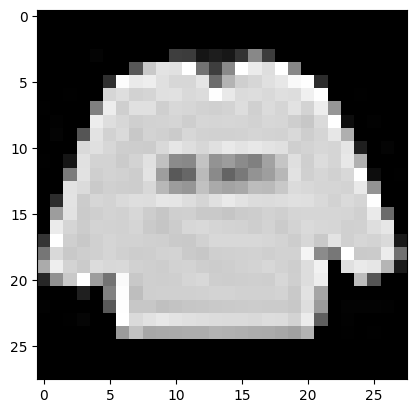

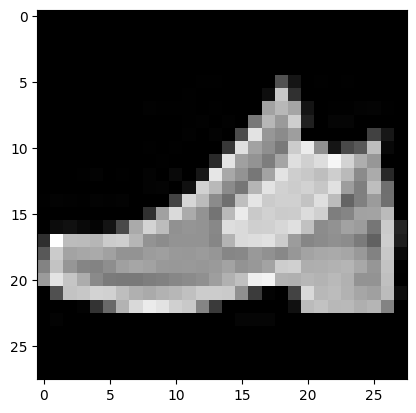

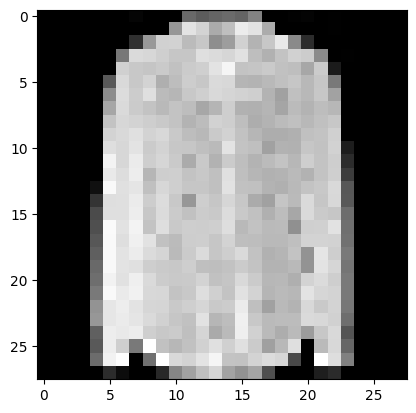

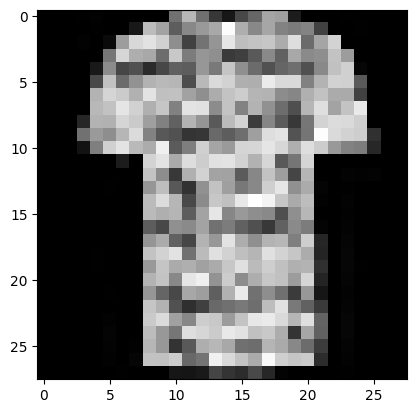

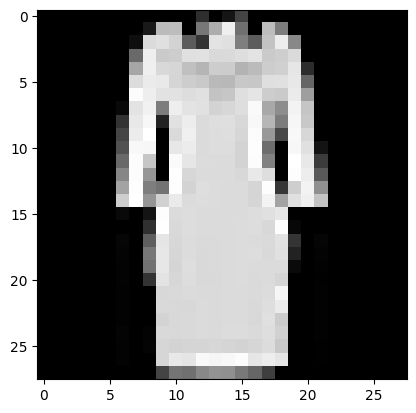

In [7]:
for i in range(5):
    feature = data.iloc[i,1:]
    feature = np.array(feature)
    feature = feature.reshape(28,28)
    plt.imshow(feature, cmap = "grey")
    plt.show()

In [20]:
X_train = data.drop('label', axis = 1)
y_train = data['label']

X_train = X_train/ 255.0
y_train = y_train/255.0

X_train = X_train.values
y_train = y_train.values

test = pd.read_csv("fashion-mnist_test.csv")
X_test = test.drop("label", axis = 1)
y_test = test["label"]
X_test = X_test.values
y_test = y_test.values




In [26]:
class CustomDataset(Dataset):
    def __init__(self, X,y):
        self.X = torch.tensor(X, dtype=torch.float32)
       
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return self.X.shape[0]
    
    def __getitem__(self,index):
        return self.X[index], self.y[index]
    
train_dataset = CustomDataset(X_train,y_train)
test_dataset = CustomDataset(X_test, y_test)
    


In [27]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, shuffle= False, batch_size = 32, pin_memory=torch.cuda.is_available())

In [30]:
class mnistFashion(nn.Module):
    def __init__(self,n_features= 784, n_labels = 10):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(n_features, 512),
            nn.ReLU,

            nn.Linear(512,256),
            nn.ReLU,

            nn.Linear(256,128),
            nn.ReLU(),

            nn.Linear(128,64),
            nn.ReLU(),

            nn.Linear(64,32),
            nn.ReLU(),

            nn.Linear(32,16),
            nn.ReLU(),

            nn.Linear(16,10)
        )
    
    def forward(self,X):
        return self.model(X)
    


